# Customer Segmentation

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("..\data\clean_sales.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
df.shape

(392692, 9)

In [4]:
df.dtypes

InvoiceNo        int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
TotalPrice     float64
dtype: object

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [6]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x : (df['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo' : 'count',
    'TotalPrice' : 'sum'
})

In [7]:
rfm

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40
...,...,...,...
18280.0,277,10,180.60
18281.0,180,7,80.82
18282.0,7,12,178.05


In [8]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [9]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [10]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
wcss    

[13014.0,
 8989.097982578034,
 5452.409460990916,
 4081.6790707267182,
 2959.8619961141662,
 2503.1030944577906,
 1925.5277327226809,
 1764.8888298924098,
 1515.8760736488878,
 1348.207844767372]

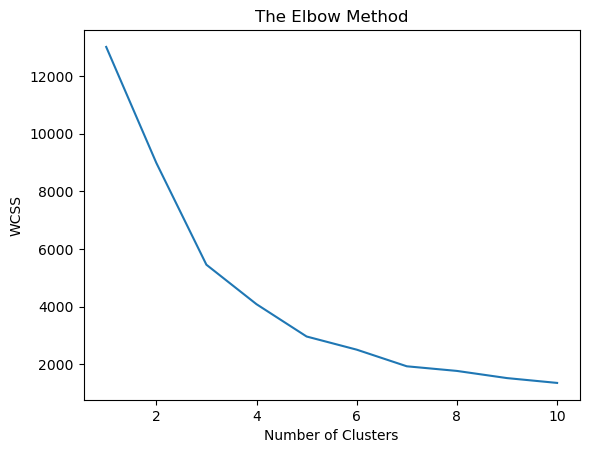

In [11]:
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS');

In [12]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [13]:
rfm

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,2
12347.0,1,182,4310.00,0
12348.0,74,31,1797.24,0
12349.0,18,73,1757.55,0
12350.0,309,17,334.40,2
...,...,...,...,...
18280.0,277,10,180.60,2
18281.0,180,7,80.82,2
18282.0,7,12,178.05,0


In [14]:
rfm.to_csv('..\data\customer_clusters.csv')
print("Customer segmentation complete. Saved to ..\data\customer_clusters.csv")

Customer segmentation complete. Saved to ..\data\customer_clusters.csv
